# FRED Data Research Notebook

This notebook is for a clean macro research workflow using FRED data. Use it to:
- define the research question
- pull the required series
- validate the data quality
- test transformations and features
- decide whether the idea should become a reusable source module or POC

## Research objective
Define the question in one sentence, for example:
- Does the yield curve slope predict recession risk?
- Does inflation persistence drive growth slowdown?
- Are interest-rate changes associated with volatility regime shifts?

In [1]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
from dotenv import load_dotenv
from fredapi import Fred

# Load project-local .env automatically
project_root = Path.cwd().resolve().parent if "notebooks" in str(Path.cwd()) else Path.cwd().resolve()
env_path = project_root / ".env"
if env_path.exists():
    load_dotenv(env_path, override=False)
else:
    print(f"No .env file found at {env_path}. Create it from .env.example and add your FRED key.")

# Configuration
API_KEY = os.getenv("FRED_API_KEY")
if not API_KEY:
    raise ValueError("Set FRED_API_KEY in .env before running this notebook.")

fred = Fred(api_key=API_KEY)

research_question = "How do macro rates and inflation behave during stress periods?"
print("Research question:", research_question)

Research question: How do macro rates and inflation behave during stress periods?


## 1. Select the FRED series
Pick the series that map to your hypothesis.

Common macro series:
- `FEDFUNDS` — Federal Funds Rate
- `CPIAUCSL` — CPI Level
- `CPILFESL` — Core CPI
- `UNRATE` — Unemployment Rate
- `GDPC1` — Real GDP
- `DGS10` — 10Y Treasury Yield
- `DGS3MO` — 3M Treasury Yield

In [2]:
series_map = {
    "fed_funds": "FEDFUNDS",
    "cpi": "CPIAUCSL",
    "core_cpi": "CPILFESL",
    "unemployment": "UNRATE",
    "treasury_10y": "DGS10",
    "treasury_3m": "DGS3MO",
}

print("Selected FRED series:")
for name, sid in series_map.items():
    print(f"- {name}: {sid}")

Selected FRED series:
- fed_funds: FEDFUNDS
- cpi: CPIAUCSL
- core_cpi: CPILFESL
- unemployment: UNRATE
- treasury_10y: DGS10
- treasury_3m: DGS3MO


In [3]:
# Pull macro data
start_date = "2010-01-01"
end_date = None
frequency = "m"

frames = {}
for name, sid in series_map.items():
    s = fred.get_series(
        sid,
        observation_start=start_date,
        observation_end=end_date,
        frequency=frequency,
    )
    frames[name] = s.rename(name)

macro_df = pd.concat(frames, axis=1).sort_index()
print(macro_df.head())
print(f"\nShape: {macro_df.shape}")

            fed_funds      cpi  core_cpi  unemployment  treasury_10y  \
2010-01-01       0.11  217.488   220.633           9.8          3.73   
2010-02-01       0.13  217.281   220.731           9.8          3.69   
2010-03-01       0.16  217.353   220.783           9.9          3.73   
2010-04-01       0.20  217.403   220.822           9.9          3.85   
2010-05-01       0.20  217.290   220.962           9.6          3.42   

            treasury_3m  
2010-01-01         0.06  
2010-02-01         0.11  
2010-03-01         0.15  
2010-04-01         0.16  
2010-05-01         0.16  

Shape: (201, 6)


## 2. Validate FRED data quality
Check missing data, duplicates, and basic consistency.

In [4]:
# Validate data quality
if macro_df.empty:
    raise ValueError("FRED data is empty.")

assert not macro_df.index.has_duplicates, "Duplicate dates found."
missing = macro_df.isna().sum()
print("Missing values:\n", missing[missing > 0])

macro_df = macro_df.dropna()
print("Cleaned shape:", macro_df.shape)

Missing values:
 fed_funds       1
cpi             2
core_cpi        2
unemployment    2
treasury_10y    1
treasury_3m     1
dtype: int64
Cleaned shape: (199, 6)


In [5]:
# Quick summary statistics
summary = macro_df.describe().T
print(summary.round(4))

              count      mean      std      min      25%      50%       75%  \
fed_funds     199.0    1.4915   1.8252    0.050    0.100    0.370    2.4000   
cpi           199.0  260.9834  34.3761  217.199  235.315  250.227  293.1055   
core_cpi      199.0  265.4167  35.1090  220.633  236.405  256.630  293.0565   
unemployment  199.0    5.6503   2.1758    3.400    4.000    4.700    7.2000   
treasury_10y  199.0    2.6769   1.0394    0.620    1.920    2.530    3.5250   
treasury_3m   199.0    1.5131   1.8986    0.010    0.065    0.300    2.4350   

                  max  
fed_funds       5.330  
cpi           334.131  
core_cpi      337.765  
unemployment   14.800  
treasury_10y    4.800  
treasury_3m     5.600  


## 3. Create macro features
Create simple economically meaningful transforms.

In [6]:
# Macro feature engineering
features = macro_df.copy()
features["term_spread"] = features["treasury_10y"] - features["treasury_3m"]
features["cpi_yoy"] = features["cpi"].pct_change(12) * 100
features["fed_funds_12m_change"] = features["fed_funds"].pct_change(12) * 100
features["unemployment_12m_change"] = features["unemployment"].diff(12)

print(features[["term_spread", "cpi_yoy", "fed_funds_12m_change", "unemployment_12m_change"]].tail())

            term_spread   cpi_yoy  fed_funds_12m_change  \
2026-04-01         0.62  3.947027            -15.935335   
2026-05-01         0.79  4.270033            -16.166282   
2026-06-01         0.66  3.726530            -16.166282   
2026-07-01         0.73  3.539751            -16.166282   
2026-08-01         0.80  3.712958            -16.166282   

            unemployment_12m_change  
2026-04-01                      0.1  
2026-05-01                      0.1  
2026-06-01                     -0.1  
2026-07-01                      0.0  
2026-08-01                     -0.2  


## 4. Plot the core relationships
Use a simple chart to inspect the relationship visually.

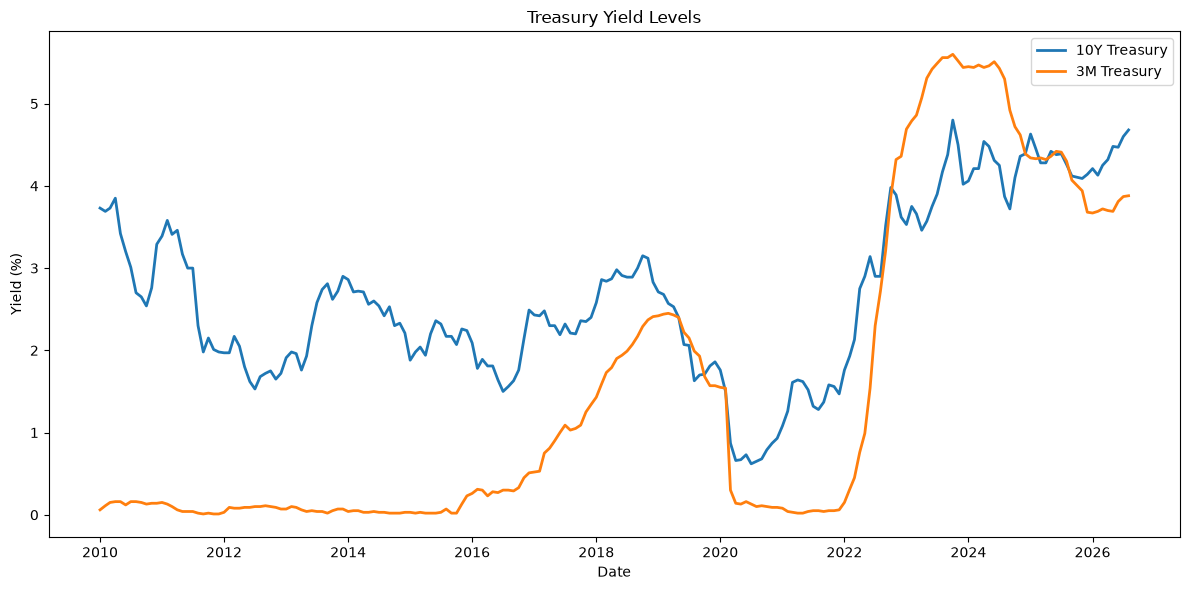

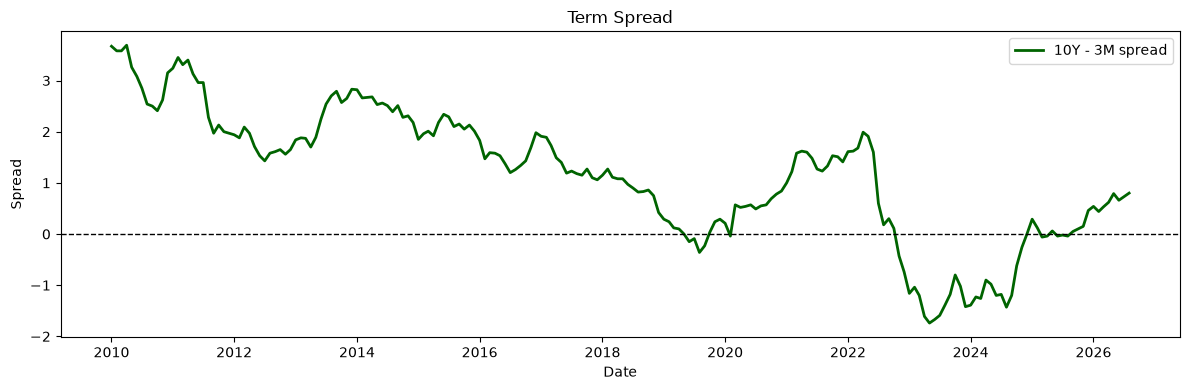

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(features["treasury_10y"], label="10Y Treasury", linewidth=2)
plt.plot(features["treasury_3m"], label="3M Treasury", linewidth=2)
plt.title("Treasury Yield Levels")
plt.xlabel("Date")
plt.ylabel("Yield (%)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(features["term_spread"], label="10Y - 3M spread", color="darkgreen", linewidth=2)
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Term Spread")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Interpret the signal
Document what the data suggests before moving into a more formal strategy.

Possible interpretations:
- widening term spread -> stronger growth expectations
- rising inflation -> policy pressure and risk-off environment
- unemployment drift -> cyclical stress signal

In [8]:
# Example result summary
interpretation = {
    "question": research_question,
    "status": "prototype",
    "next_step": "Convert this notebook logic into a reusable macro signal module or POC script.",
}

print(interpretation)

{'question': 'How do macro rates and inflation behave during stress periods?', 'status': 'prototype', 'next_step': 'Convert this notebook logic into a reusable macro signal module or POC script.'}


## 6. Final decision
Decide if this should become:
- a reusable data ingestion module
- a macro feature engineering script
- a strategy idea
- a full alpha research workflow